In [9]:
# %%
# =============================================================================
# Célula 1: Imports e Configurações Globais
# =============================================================================
import pandas as pd
import numpy as np
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import traceback
from tqdm.notebook import tqdm
from datetime import datetime
import random
from sklearn.metrics import accuracy_score, f1_score

# --- Imports da Biblioteca ---
try:
    from activetextclassification.data_preparation import load_and_prepare_data, preprocess_label # Adicionar preprocess_label
    from activetextclassification.models import get_model, BaseTextClassifier # Assumindo PVBin é BaseTextClassifier
    # from activetextclassification.embeddings import get_embedder # Se usar classificador baseado em features
    print("Módulos da biblioteca activetextclassification importados.")
except Exception as e:
    print(f"ERRO ao importar biblioteca: {e}"); raise e

# --- Autoreload ---
try:
    %load_ext autoreload
    %autoreload 2
    print("Autoreload ativado.")
except Exception: pass

# --- Parâmetros do Experimento ---
# <<< MUDE AQUI CONFORME NECESSÁRIO >>>
DATA_FILE = '../data/dataset.csv'
TEXT_COLUMN = 'nm_item'
LABEL_COLUMN = 'nm_product'
MIN_SAMPLES_PREPROC = 5
RARE_LABEL_PREPROC = "_RARE_"

# Configuração do Classificador a ser testado
CLASSIFIER_CONFIG = {
    'type': 'PVBin', # ProductVectorizer Binário
    'params': {'method':'binary', 'query':'binary', 'norm':None, 'query_norm':None, 'ngram_range': [1,2]}
}

# Tamanhos da Amostra Inicial (L0) a serem testados
sample_sizes_L0 = list(range(10, 101, 10)) + \
                  list(range(200, 1001, 100)) + \
                  list(range(2000, 10001, 1000)) + \
                  list(range(20000, 200001, 10000)) # Até 200k (ajuste o limite superior se necessário)
# Remover duplicatas e ordenar (caso haja sobreposição, ex: se 100 já estava)
sample_sizes_L0 = sorted(list(set(sample_sizes_L0)))

N_REPETITIONS = 30 # Número de simulações (sementes aleatórias) para cada tamanho
POPULATION_TEST_SIZE = 0.20 # 20% reservado para População de Teste (P)
                             # 80% será o Pool de Treinamento (U_pool) de onde L0 é amostrado

OUTPUT_FILE_METRICS = f"./data/sensibilidade/l0_random_impact_metrics_{CLASSIFIER_CONFIG['type']}.xlsx"
OUTPUT_FILE_STATS_TABLE_LATEX = f"./data/sensibilidade/l0_random_impact_stats_table_{CLASSIFIER_CONFIG['type']}.tex"
BASE_RANDOM_SEED = 42
# <<< FIM MUDE AQUI >>>

print(f"Experimento: Impacto da Amostragem Aleatória de L0")
print(f"Dataset: {DATA_FILE}")
print(f"Classificador: {CLASSIFIER_CONFIG['type']}")
print(f"Tamanhos de L0 (I) a serem testados: {len(sample_sizes_L0)} tamanhos, de {min(sample_sizes_L0)} a {max(sample_sizes_L0)}")
print(f"Repetições por Tamanho: {N_REPETITIONS}")
print(f"Tamanho da População de Teste (P): {POPULATION_TEST_SIZE*100:.0f}%")
print(f"Arquivo de Métricas: {OUTPUT_FILE_METRICS}")
print(f"Arquivo da Tabela LaTeX: {OUTPUT_FILE_STATS_TABLE_LATEX}")

Módulos da biblioteca activetextclassification importados.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Autoreload ativado.
Experimento: Impacto da Amostragem Aleatória de L0
Dataset: ../data/dataset.csv
Classificador: PVBin
Tamanhos de L0 (I) a serem testados: 47 tamanhos, de 10 a 200000
Repetições por Tamanho: 30
Tamanho da População de Teste (P): 20%
Arquivo de Métricas: ./data/sensibilidade/l0_random_impact_metrics_PVBin.xlsx
Arquivo da Tabela LaTeX: ./data/sensibilidade/l0_random_impact_stats_table_PVBin.tex


In [4]:
# %%
# =============================================================================
# Célula 2: Carregar, Pré-processar e Particionar o Dataset
# =============================================================================
print("\n--- Carregando e Preparando Dataset Completo ---")

df_full = None
all_possible_labels = [] # Labels únicos após pré-processamento e agrupamento raro
df_population_test = None # P (20%)
df_training_pool = None   # U_pool (80%)

try:
    # 1. Obter lista de labels válidos e fazer pré-proc inicial no dataset completo
    print(f"Pré-processando labels e agrupando classes raras de '{DATA_FILE}'...")
    # Usar load_and_prepare para obter o DF completo já pré-processado e os labels
    # Modificamos load_and_prepare_data para retornar o DF completo se split_pu=False
    # Se sua função não foi modificada, precisaremos do workaround:
    # _, _, _, _, all_possible_labels = load_and_prepare_data(
    #     file_path=DATA_FILE, text_column=TEXT_COLUMN, label_column=LABEL_COLUMN,
    #     min_samples_per_class=MIN_SAMPLES_PREPROC, rare_group_label=RARE_LABEL_PREPROC,
    #     population_size=0.99, # Só para rodar e pegar labels
    #     split_pu=False # Assumindo que você adicionou este parâmetro
    # )
    # if not all_possible_labels: raise ValueError("Nenhum label encontrado.")
    # print(f"Labels únicos finais ({len(all_possible_labels)}): {all_possible_labels[:10]}...")

    # Abordagem SEM modificar load_and_prepare_data:
    temp_P, temp_U, _, _, all_possible_labels = load_and_prepare_data(
        file_path=DATA_FILE, text_column=TEXT_COLUMN, label_column=LABEL_COLUMN,
        min_samples_per_class=MIN_SAMPLES_PREPROC, rare_group_label=RARE_LABEL_PREPROC,
        population_size=POPULATION_TEST_SIZE, # Usar o tamanho real de P aqui
        random_seed=BASE_RANDOM_SEED # Usar uma seed para este split inicial
    )
    if not all_possible_labels: raise ValueError("Nenhum label encontrado.")
    print(f"Labels únicos finais ({len(all_possible_labels)}): {all_possible_labels[:10]}...")
    df_population_test = temp_P.copy()
    df_training_pool = temp_U.copy() # Este é o pool de onde L0 será amostrado
    del temp_P, temp_U
    print(f"Dataset particionado: {len(df_training_pool)} no Pool de Treinamento, {len(df_population_test)} na População de Teste.")

    if df_training_pool.empty: raise ValueError("Pool de Treinamento está vazio após particionamento.")
    if df_population_test.empty: raise ValueError("População de Teste está vazia.")

except Exception as e:
    print(f"ERRO CRÍTICO ao preparar dados: {e}")
    traceback.print_exc()
    raise SystemExit("Não foi possível preparar os dados.")


--- Carregando e Preparando Dataset Completo ---
Pré-processando labels e agrupando classes raras de '../data/dataset.csv'...
--- Iniciando Preparação de Dados ---
Carregando dados de: ../data/dataset.csv
Shape inicial: (250365, 2)
Shape após remover NaNs: (250365, 2) (0 linhas removidas)
Pré-processando rótulos...
Verificando classes com menos de 5 amostras...
Agrupando 174 classes raras em '_RARE_': ['soquete', 'jabuticaba', 'jogo de carta', 'farinha sem gluten', 'escada', 'maria mole', 'impressora', 'analgesico veterinario', 'estojo', 'quadro']...
Distribuição de classes após agrupamento:
nm_product
biscoito                                 14292
iogurte                                   7520
chocolate                                 6732
padaria e confeitaria industrializado     6046
aperitivo                                 5186
Name: count, dtype: int64
Mapeamento de rótulos finalizado: 622 classes (incluindo '_RARE_' se criado).
Dividindo em População (P = 20%) e Pool (U)...
Tam

In [ ]:
# %%
# =============================================================================
# Célula 3: Loop Principal do Experimento
# =============================================================================
print("\n--- Iniciando Simulações de Impacto de L0 Aleatório ---")

all_run_metrics = [] # Lista para armazenar os resultados de cada simulação

# Loop pelos tamanhos de amostra inicial L0
for l0_size in tqdm(sample_sizes_L0, desc="Tamanhos de L0 (I)"):

    # Verificar se o tamanho de L0 é viável para o df_training_pool
    if l0_size > len(df_training_pool):
        print(f"AVISO: Tamanho de L0 {l0_size} é maior que o Training Pool ({len(df_training_pool)}). Pulando este tamanho.")
        continue
    if l0_size <= 0:
        print(f"AVISO: Tamanho de L0 inválido {l0_size}. Pulando.")
        continue

    print(f"\n--- Testando Tamanho de L0 (I) = {l0_size} ---")

    # Loop pelas N_REPETITIONS para este tamanho de L0
    for rep in tqdm(range(N_REPETITIONS), desc=f"Repetições para I={l0_size}", leave=False):
        current_seed = BASE_RANDOM_SEED + rep + l0_size # Semente única para cada simulação
        np.random.seed(current_seed)
        random.seed(current_seed)

        # print(f"  Repetição {rep+1}/{N_REPETITIONS} (Seed: {current_seed})...", end="")
        accuracy_pop, f1_macro_pop, train_time = np.nan, np.nan, np.nan

        try:
            # 1. Selecionar L0 aleatoriamente do df_training_pool (80% do dataset)
            # Garantir que não tentamos amostrar mais do que o disponível
            actual_l0_size_to_sample = min(l0_size, len(df_training_pool))
            L0_current_df = df_training_pool.sample(n=actual_l0_size_to_sample, random_state=current_seed)

            # 2. Preparar dados para o modelo
            X_train_l0 = L0_current_df[TEXT_COLUMN].tolist()
            y_train_l0 = L0_current_df[LABEL_COLUMN].tolist()

            # 3. Instanciar e Treinar Modelo em L0
            model_instance = get_model(CLASSIFIER_CONFIG) # Nova instância a cada vez
            start_train_time = time.time()
            if isinstance(model_instance, BaseTextClassifier):
                 model_instance.fit(X_train_l0, y_train_l0)
            else: # Assumindo que outros tipos precisariam de embeddings
                 raise NotImplementedError(f"Treinamento para tipo de modelo {type(model_instance)} não implementado neste script (esperava BaseTextClassifier).")
            train_time = time.time() - start_train_time

            # 4. Avaliar na População de Teste (df_population_test - 20% do dataset)
            X_eval_pop = df_population_test[TEXT_COLUMN].tolist()
            y_true_pop = df_population_test[LABEL_COLUMN].tolist()

            if isinstance(model_instance, BaseTextClassifier):
                 y_pred_pop = model_instance.predict(X_eval_pop)
            else:
                 raise NotImplementedError("Predição não implementada para este tipo de modelo.")

            accuracy_pop = accuracy_score(y_true_pop, y_pred_pop)
            f1_macro_pop = f1_score(y_true_pop, y_pred_pop, average='macro', zero_division=0, labels=all_possible_labels)
            # print(f" -> Acc={accuracy_pop:.4f}, F1={f1_macro_pop:.4f}, Treino={train_time:.2f}s")

        except Exception as iter_e:
             print(f" -> ERRO na Rep {rep+1} para L0Tam={l0_size}: {type(iter_e).__name__} - {iter_e}")
             # As métricas permanecerão NaN

        # 5. Registrar Resultados
        all_run_metrics.append({
            'l0_size': l0_size,
            'repetition': rep + 1,
            'random_seed_used': current_seed,
            'accuracy_on_population': accuracy_pop,
            'f1_macro_on_population': f1_macro_pop,
            'train_time_sec': train_time
        })

print("\n--- Simulações Concluídas ---")

In [13]:
# %%
# =============================================================================
# Célula 4: Converter Resultados para DataFrame e Salvar
# =============================================================================
print("\n--- Processando e Salvando Resultados ---")

if not all_run_metrics:
    print("Nenhuma métrica foi registrada. Verifique os loops e logs de erro.")
    # raise SystemExit("Nenhum resultado para processar.")
else:
    results_df = pd.DataFrame(all_run_metrics)
    print(f"Total de {len(results_df)} simulações (linhas) registradas.")
    print("\nPré-visualização dos Resultados:")
    display(results_df.head())

    try:
        print(f"Salvando métricas em: {OUTPUT_FILE_METRICS}")
        results_df.to_excel(OUTPUT_FILE_METRICS, index=False, engine='openpyxl')
        print("Arquivo Excel de Métricas salvo com sucesso.")
    except ImportError:
         print("AVISO: 'openpyxl' não instalado. Salvando como CSV.")
         csv_output_metrics = OUTPUT_FILE_METRICS.replace('.xlsx','.csv')
         try: results_df.to_csv(csv_output_metrics, index=False, encoding='utf-8-sig'); print(f"Salvo como CSV: {csv_output_metrics}")
         except Exception as e_csv: print(f"Erro ao salvar CSV de métricas: {e_csv}")
    except Exception as e_xls:
         print(f"Erro ao salvar Excel de métricas: {e_xls}")


--- Processando e Salvando Resultados ---
Total de 1410 simulações (linhas) registradas.

Pré-visualização dos Resultados:


,l0_size,repetition,random_seed_used,accuracy_on_population,f1_macro_on_population,train_time_sec
0,10,1,52,0.078765,0.003923,0.000000
1,10,2,53,0.036107,0.002612,0.004020
2,10,3,54,0.025603,0.002411,0.004024
3,10,4,55,0.092106,0.003970,0.002009
4,10,5,56,0.059733,0.003279,0.005433


Salvando métricas em: ./data/sensibilidade/l0_random_impact_metrics_PVBin.xlsx
Arquivo Excel de Métricas salvo com sucesso.


In [14]:
# %%
# =============================================================================
# Célula 5: Calcular Estatísticas Descritivas e Gerar Tabela LaTeX
# =============================================================================
print("\n--- Calculando Estatísticas Descritivas e Gerando Tabela LaTeX ---")

if 'results_df' in locals() and not results_df.empty:
    # Agrupar por tamanho de L0 e calcular estatísticas
    stats_summary_list = []
    for metric_col, metric_name in [('accuracy_on_population', 'Acurácia'),
                                    ('f1_macro_on_population', 'F1-Macro')]:
        if metric_col not in results_df.columns:
            print(f"Coluna '{metric_col}' não encontrada para estatísticas.")
            continue

        # Filtrar NaNs da coluna da métrica antes de agrupar para describe()
        valid_metric_df = results_df.dropna(subset=[metric_col])
        if valid_metric_df.empty:
            print(f"Sem dados válidos para a métrica '{metric_name}' após remover NaNs.")
            continue

        stats = valid_metric_df.groupby('l0_size')[metric_col].agg(
            Média='mean',
            DesvioPadrão='std',
            Mínimo='min',
            P25=lambda x: x.quantile(0.25),
            Mediana='median',
            P75=lambda x: x.quantile(0.75),
            Máximo='max'
        ).reset_index()

        # Calcular IQR e Coeficiente de Variação
        stats['IQR'] = stats['P75'] - stats['P25']
        # Adicionar epsilon para evitar divisão por zero no Coeficiente de Variação se a média for 0
        stats['CV (Média != 0)'] = stats['DesvioPadrão'] / (stats['Média'] + 1e-9)
        stats['CV (Mediana != 0)'] = stats['DesvioPadrão'] / (stats['Mediana'] + 1e-9)

        stats['Métrica'] = metric_name
        stats_summary_list.append(stats)

    if stats_summary_list:
        full_stats_df = pd.concat(stats_summary_list, ignore_index=True)
        # Reordenar colunas
        cols_order_stats = ['Métrica', 'l0_size', 'Média', 'Mediana', 'DesvioPadrão', 'Mínimo', 'P25', 'P75', 'Máximo', 'IQR', 'CV (Média != 0)', 'CV (Mediana != 0)']
        full_stats_df = full_stats_df[cols_order_stats]

        print("\nEstatísticas Descritivas Consolidadas:")
        display(full_stats_df)

        # Gerar Tabela LaTeX
        print(f"\nGerando Tabela LaTeX para: {OUTPUT_FILE_STATS_TABLE_LATEX}")
        try:
            # Selecionar e renomear colunas para a tabela LaTeX
            latex_df = full_stats_df.rename(columns={
                'l0_size': 'Tam. L0 (I)',
                'DesvioPadrão': 'DP',
                'CV (Mediana != 0)': 'CV (Mediana)'
            })
            # Formatar números para LaTeX (ex: 3 casas decimais)
            float_cols = ['Média', 'Mediana', 'DP', 'Mínimo', 'P25', 'P75', 'Máximo', 'IQR', 'CV (Mediana)']
            for col in float_cols:
                if col in latex_df.columns:
                    latex_df[col] = latex_df[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "-")

            # Pivota a tabela para ter Métricas como agrupador de linhas e estatísticas como sub-linhas
            # Ou, mais simples, gerar uma tabela para cada métrica
            # Vamos gerar uma tabela longa com Métrica como primeira coluna

            latex_table_string = latex_df[
                ['Métrica', 'Tam. L0 (I)', 'Média', 'Mediana', 'DP', 'Mínimo', 'P25', 'P75', 'Máximo', 'IQR', 'CV (Mediana)']
            ].to_latex(index=False, escape=False, column_format='ll|rrrrrrr|rr', multicolumn_format='c',
                         caption=f"Estatísticas Descritivas da Performance em Função do Tamanho de L0 (Classificador: {CLASSIFIER_CONFIG['type']}).",
                         label="tab:l0_random_stats_summary")

            # Pequenos ajustes na string LaTeX (ex: \toprule, \midrule)
            latex_table_string = latex_table_string.replace("\\begin{tabular}", "\\centering\n\\begin{tabular}")
            latex_table_string = latex_table_string.replace("NaN", "-") # Substituir NaN por hífen

            with open(OUTPUT_FILE_STATS_TABLE_LATEX, 'w', encoding='utf-8') as f:
                f.write("\\begin{table}[htbp]\n")
                # Adicionar \scriptsize ou \footnotesize para diminuir a fonte da tabela se necessário
                f.write(latex_table_string)
                f.write("\\end{table}\n")
            print(f"Tabela LaTeX salva em: {OUTPUT_FILE_STATS_TABLE_LATEX}")
            print("\nConteúdo da Tabela LaTeX (para copiar e colar):")
            print(latex_table_string)

        except Exception as e_latex:
            print(f"Erro ao gerar tabela LaTeX: {e_latex}")
    else:
        print("Nenhuma estatística calculada para gerar tabela LaTeX.")
else:
    print("DataFrame de resultados vazio. Nenhuma estatística ou tabela LaTeX gerada.")


--- Calculando Estatísticas Descritivas e Gerando Tabela LaTeX ---

Estatísticas Descritivas Consolidadas:


,Métrica,l0_size,Média,Mediana,DesvioPadrão,Mínimo,P25,P75,Máximo,IQR,CV (Média != 0),CV (Mediana != 0)
0,Acurácia,10,0.066649,0.068869,0.023793,0.025603,0.045918,0.088246,0.102171,0.042328,0.356997,0.345485
1,Acurácia,20,0.105012,0.110059,0.023253,0.049388,0.089185,0.121807,0.138118,0.032622,0.221429,0.211274
2,Acurácia,30,0.139531,0.138678,0.022874,0.095281,0.125312,0.155383,0.181395,0.030071,0.163936,0.164945
3,Acurácia,40,0.159713,0.159447,0.022555,0.100274,0.144589,0.178245,0.191021,0.033656,0.141224,0.141460
4,Acurácia,50,0.178486,0.179758,0.021830,0.124079,0.164435,0.198550,0.208496,0.034115,0.122305,0.121440
...,...,...,...,...,...,...,...,...,...,...,...,...
89,F1-Macro,160000,0.688752,0.688245,0.003703,0.681760,0.686785,0.690993,0.700429,0.004208,0.005376,0.005380
90,F1-Macro,170000,0.693007,0.693140,0.002942,0.687723,0.690346,0.695466,0.698889,0.005120,0.004245,0.004244
91,F1-Macro,180000,0.698289,0.698678,0.002964,0.692119,0.696257,0.700335,0.703808,0.004078,0.004244,0.004242
92,F1-Macro,190000,0.700854,0.700615,0.002355,0.694611,0.699792,0.701759,0.706399,0.001968,0.003360,0.003361



Gerando Tabela LaTeX para: ./data/sensibilidade/l0_random_impact_stats_table_PVBin.tex
Tabela LaTeX salva em: ./data/sensibilidade/l0_random_impact_stats_table_PVBin.tex

Conteúdo da Tabela LaTeX (para copiar e colar):
\begin{table}
\caption{Estatísticas Descritivas da Performance em Função do Tamanho de L0 (Classificador: PVBin).}
\label{tab:l0_random_stats_summary}
\centering
\begin{tabular}{ll|rrrrrrr|rr}
\toprule
Métrica & Tam. L0 (I) & Média & Mediana & DP & Mínimo & P25 & P75 & Máximo & IQR & CV (Mediana) \\
\midrule
Acurácia & 10 & 0.067 & 0.069 & 0.024 & 0.026 & 0.046 & 0.088 & 0.102 & 0.042 & 0.345 \\
Acurácia & 20 & 0.105 & 0.110 & 0.023 & 0.049 & 0.089 & 0.122 & 0.138 & 0.033 & 0.211 \\
Acurácia & 30 & 0.140 & 0.139 & 0.023 & 0.095 & 0.125 & 0.155 & 0.181 & 0.030 & 0.165 \\
Acurácia & 40 & 0.160 & 0.159 & 0.023 & 0.100 & 0.145 & 0.178 & 0.191 & 0.034 & 0.141 \\
Acurácia & 50 & 0.178 & 0.180 & 0.022 & 0.124 & 0.164 & 0.199 & 0.208 & 0.034 & 0.121 \\
Acurácia & 60 & 0.193 & 0

In [22]:
acc_data_to_plot[0]

array([0.078765  , 0.03610728, 0.02560262, 0.09210553, 0.05973279,
       0.06919897, 0.09703832, 0.04844926, 0.09791704, 0.05693687,
       0.09284445, 0.05877419, 0.08509576, 0.08727258, 0.08903002,
       0.06853993, 0.08857069, 0.03490903, 0.08006311, 0.03063527,
       0.07017754, 0.10099255, 0.0434965 , 0.04269766, 0.04507419,
       0.07568949, 0.05326224, 0.10217083, 0.05717652, 0.03113454])


--- Plotando Boxplot Evolutivo da Acurácia ---


C:\Users\ghdaru\AppData\Local\Temp\ipykernel_35828\968595113.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel2', len(valid_l0_sizes_for_plot))


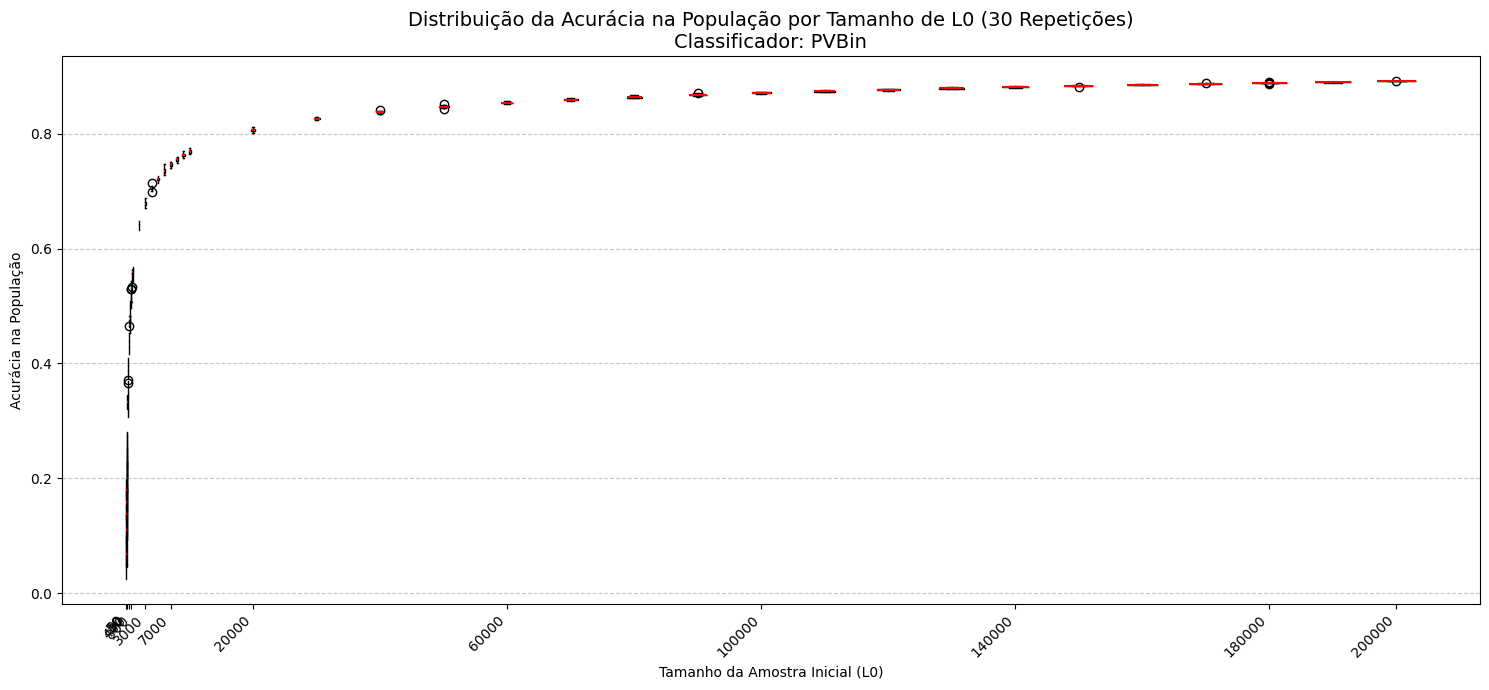


--- Plotando Boxplot Evolutivo do F1-Score ---


C:\Users\ghdaru\AppData\Local\Temp\ipykernel_35828\968595113.py:109: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Pastel1', len(valid_l0_sizes_for_plot_f1))


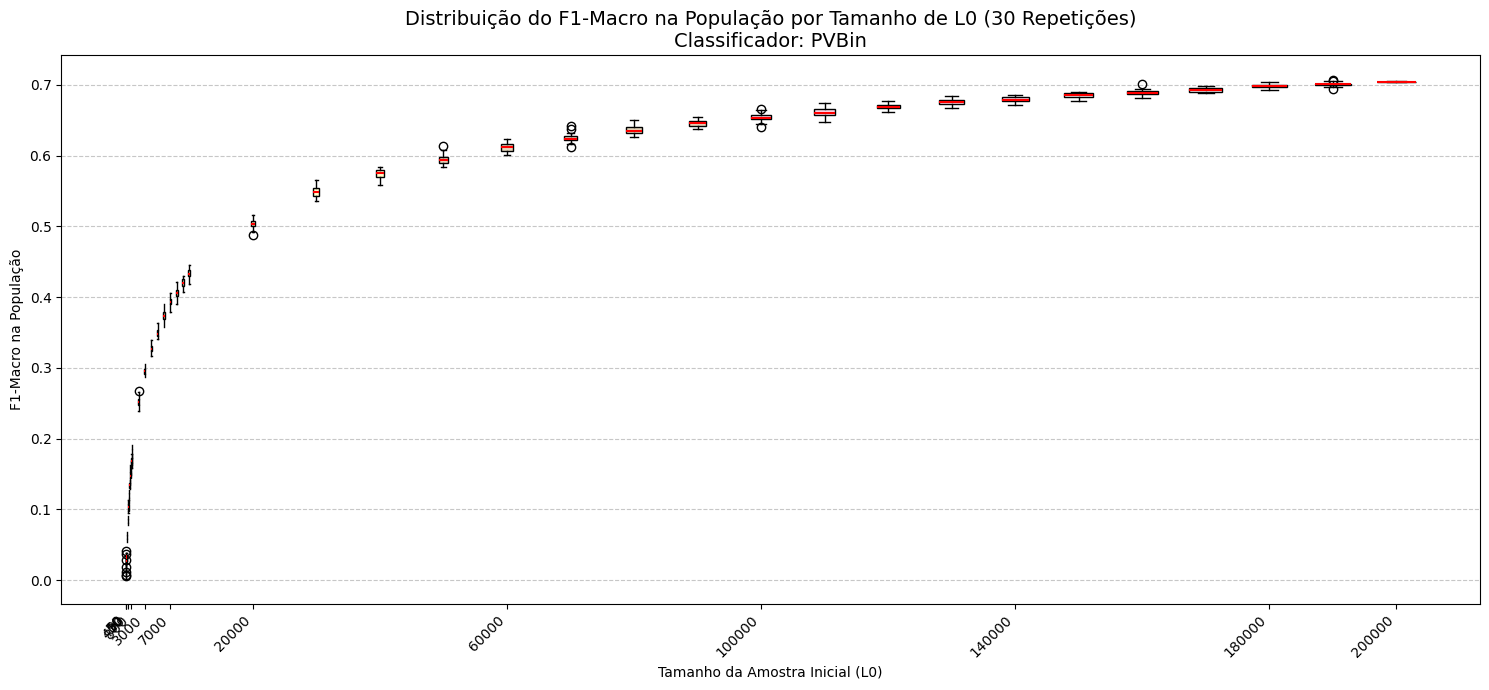

In [20]:
# %%
# =============================================================================
# Célula 6: Plotagem - Boxplot Evolutivo da ACURÁCIA
# =============================================================================
print("\n--- Plotando Boxplot Evolutivo da Acurácia ---")

if 'results_df' in locals() and not results_df.empty:
    if results_df['l0_size'].nunique() < 1:
        print("AVISO: Menos de um tamanho de L0 distinto ou nenhum dado. Boxplot não será gerado.")
    else:
        try:
            plt.figure(figsize=(15, 7)) # Ajustar tamanho conforme necessário
            unique_l0_sizes_sorted = sorted(results_df['l0_size'].unique())

            acc_data_to_plot = [results_df[results_df['l0_size'] == size]['accuracy_on_population'].dropna().values for size in unique_l0_sizes_sorted]
            
            # Filtrar tamanhos onde não há dados válidos para evitar erro no boxplot
            valid_acc_data = []
            valid_l0_sizes_for_plot = []
            for i, data_array in enumerate(acc_data_to_plot):
                if len(data_array) > 0:
                    valid_acc_data.append(data_array)
                    valid_l0_sizes_for_plot.append(unique_l0_sizes_sorted[i])
            
            if valid_acc_data:
                bp_acc = plt.boxplot(valid_acc_data,
                                     positions=valid_l0_sizes_for_plot,
                                     widths=np.array(valid_l0_sizes_for_plot) * 0.03 + 50, # Ajustar fator de largura
                                     manage_ticks=False,
                                     patch_artist=True,
                                     medianprops=dict(color="red", linewidth=1.5))

                plt.title(f'Distribuição da Acurácia na População por Tamanho de L0 ({N_REPETITIONS} Repetições)\nClassificador: {CLASSIFIER_CONFIG["type"]}', fontsize=14)
                plt.xlabel('Tamanho da Amostra Inicial (L0)')
                plt.ylabel('Acurácia na População')
                plt.xticks(rotation=45, ha='right')
                plt.grid(axis='y', linestyle='--', alpha=0.7)

                # Definir ticks do eixo X para melhor visualização
                tick_positions_acc = valid_l0_sizes_for_plot
                if len(valid_l0_sizes_for_plot) > 15: # Mostrar menos ticks se houver muitos
                    step = max(1, len(valid_l0_sizes_for_plot) // 10)
                    tick_positions_acc = valid_l0_sizes_for_plot[::step]
                    if valid_l0_sizes_for_plot[-1] not in tick_positions_acc:
                         tick_positions_acc = np.append(tick_positions_acc, valid_l0_sizes_for_plot[-1])
                plt.xticks(tick_positions_acc)

                # Opcional: Preencher cores
                colors = plt.cm.get_cmap('Pastel2', len(valid_l0_sizes_for_plot))
                for patch, color_idx in zip(bp_acc['boxes'], range(len(valid_l0_sizes_for_plot))):
                    patch.set_facecolor(colors(color_idx % colors.N))

                plt.tight_layout()
                plt.show()
            else:
                print("Nenhum dado válido de acurácia para plotar o boxplot.")

        except Exception as plot_e:
            print(f"Erro durante a plotagem do boxplot de acurácia: {plot_e}")
            traceback.print_exc()
else:
    print("Nenhum resultado ('results_df') para plotar boxplot de acurácia.")

# %%
# =============================================================================
# Célula 7: Plotagem - Boxplot Evolutivo do F1-SCORE
# =============================================================================
print("\n--- Plotando Boxplot Evolutivo do F1-Score ---")

if 'results_df' in locals() and not results_df.empty:
    if results_df['l0_size'].nunique() < 1:
        print("AVISO: Menos de um tamanho de L0 distinto ou nenhum dado. Boxplot não será gerado.")
    else:
        try:
            plt.figure(figsize=(15, 7))
            unique_l0_sizes_sorted = sorted(results_df['l0_size'].unique())

            f1_data_to_plot = [results_df[results_df['l0_size'] == size]['f1_macro_on_population'].dropna().values for size in unique_l0_sizes_sorted]

            valid_f1_data = []
            valid_l0_sizes_for_plot_f1 = []
            for i, data_array in enumerate(f1_data_to_plot):
                if len(data_array) > 0:
                    valid_f1_data.append(data_array)
                    valid_l0_sizes_for_plot_f1.append(unique_l0_sizes_sorted[i])
            
            if valid_f1_data:
                bp_f1 = plt.boxplot(valid_f1_data,
                                    positions=valid_l0_sizes_for_plot_f1,
                                    widths=np.array(valid_l0_sizes_for_plot_f1) * 0.03 + 50, # Ajustar
                                    manage_ticks=False,
                                    patch_artist=True,
                                    medianprops=dict(color="red", linewidth=1.5))

                plt.title(f'Distribuição do F1-Macro na População por Tamanho de L0 ({N_REPETITIONS} Repetições)\nClassificador: {CLASSIFIER_CONFIG["type"]}', fontsize=14)
                plt.xlabel('Tamanho da Amostra Inicial (L0)')
                plt.ylabel('F1-Macro na População')
                plt.xticks(rotation=45, ha='right')
                plt.grid(axis='y', linestyle='--', alpha=0.7)

                tick_positions_f1 = valid_l0_sizes_for_plot_f1
                if len(valid_l0_sizes_for_plot_f1) > 15:
                    step = max(1, len(valid_l0_sizes_for_plot_f1) // 10)
                    tick_positions_f1 = valid_l0_sizes_for_plot_f1[::step]
                    if valid_l0_sizes_for_plot_f1[-1] not in tick_positions_f1:
                         tick_positions_f1 = np.append(tick_positions_f1, valid_l0_sizes_for_plot_f1[-1])
                plt.xticks(tick_positions_f1)
                
                colors = plt.cm.get_cmap('Pastel1', len(valid_l0_sizes_for_plot_f1))
                for patch, color_idx in zip(bp_f1['boxes'], range(len(valid_l0_sizes_for_plot_f1))):
                    patch.set_facecolor(colors(color_idx % colors.N))

                plt.tight_layout()
                plt.show()
            else:
                print("Nenhum dado válido de F1-score para plotar o boxplot.")

        except Exception as plot_e:
            print(f"Erro durante a plotagem do boxplot de F1-score: {plot_e}")
            traceback.print_exc()
else:
    print("Nenhum resultado ('results_df') para plotar boxplot de F1-score.")


--- Plotando Linhas de Tendência para Acurácia ---


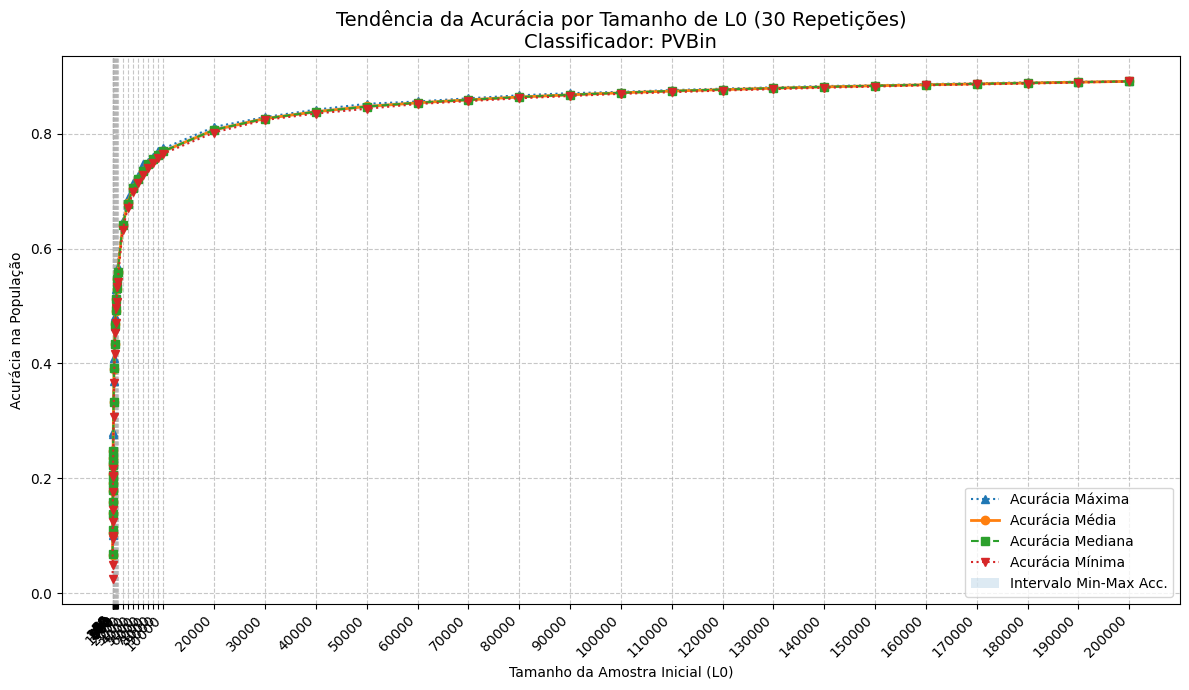


--- Plotando Linhas de Tendência para F1-Score ---


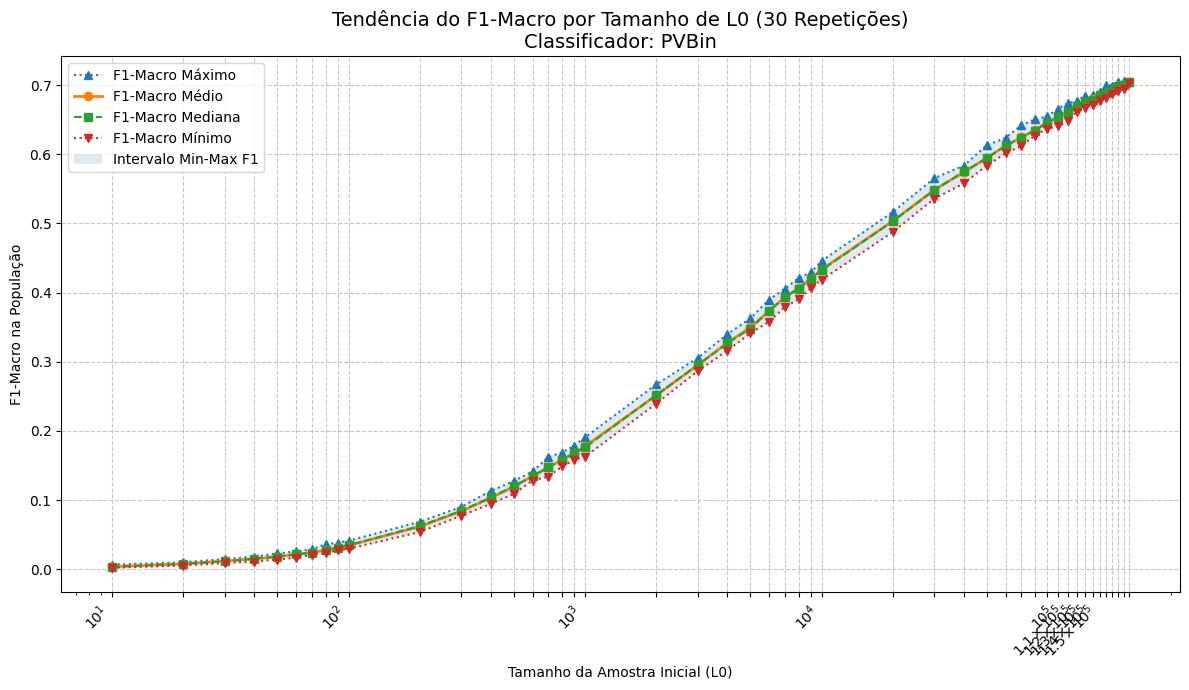


--- Plotando Boxplot Evolutivo do Desvio Padrão das Métricas ---


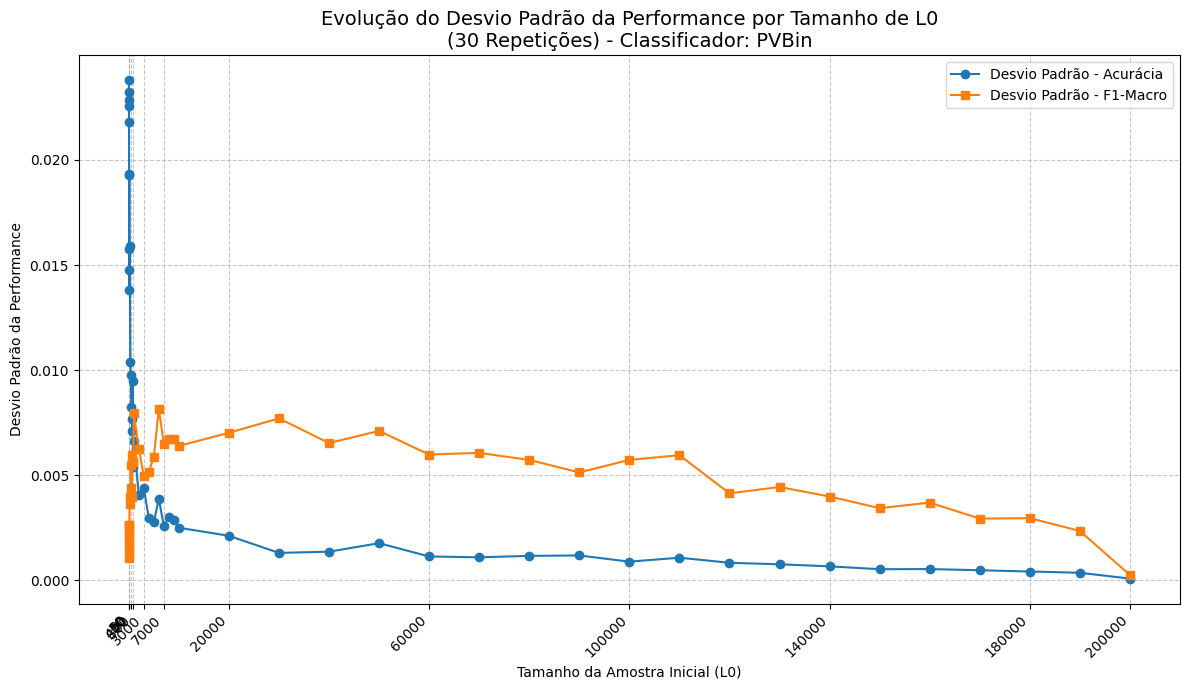

In [23]:
# %%
# =============================================================================
# Célula 8: Plotagem - Linhas de Tendência (Max, Min, Média, Mediana) - ACURÁCIA
# =============================================================================
print("\n--- Plotando Linhas de Tendência para Acurácia ---")

if 'full_stats_df' in locals() and not full_stats_df.empty:
    stats_acc_df = full_stats_df[full_stats_df['Métrica'] == 'Acurácia'].copy()
    if not stats_acc_df.empty:
        try:
            plt.figure(figsize=(12, 7))
            plt.plot(stats_acc_df['l0_size'], stats_acc_df['Máximo'], label='Acurácia Máxima', marker='^', linestyle=':')
            plt.plot(stats_acc_df['l0_size'], stats_acc_df['Média'], label='Acurácia Média', marker='o', linewidth=2)
            plt.plot(stats_acc_df['l0_size'], stats_acc_df['Mediana'], label='Acurácia Mediana', marker='s', linestyle='--')
            plt.plot(stats_acc_df['l0_size'], stats_acc_df['Mínimo'], label='Acurácia Mínima', marker='v', linestyle=':')
            
            # Opcional: Preencher a área entre Máximo e Mínimo para mostrar variabilidade
            plt.fill_between(stats_acc_df['l0_size'], stats_acc_df['Mínimo'], stats_acc_df['Máximo'], alpha=0.15, label='Intervalo Min-Max Acc.')

            plt.title(f'Tendência da Acurácia por Tamanho de L0 ({N_REPETITIONS} Repetições)\nClassificador: {CLASSIFIER_CONFIG["type"]}', fontsize=14)
            plt.xlabel('Tamanho da Amostra Inicial (L0)')
            plt.ylabel('Acurácia na População')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            # plt.xscale('log') # Usar escala log para o eixo X pode ser útil se os tamanhos variam muito
            plt.xticks(stats_acc_df['l0_size'].unique(), rotation=45, ha='right') # Mostrar todos os tamanhos testados
            plt.tight_layout()
            plt.show()
        except Exception as plot_e:
            print(f"Erro durante a plotagem das linhas de tendência de acurácia: {plot_e}")
            traceback.print_exc()
    else:
        print("Sem dados de estatísticas de acurácia para plotar.")
else:
    print("DataFrame de estatísticas ('full_stats_df') não encontrado ou vazio.")


# %%
# =============================================================================
# Célula 9: Plotagem - Linhas de Tendência (Max, Min, Média, Mediana) - F1-SCORE
# =============================================================================
print("\n--- Plotando Linhas de Tendência para F1-Score ---")

if 'full_stats_df' in locals() and not full_stats_df.empty:
    stats_f1_df = full_stats_df[full_stats_df['Métrica'] == 'F1-Macro'].copy()
    if not stats_f1_df.empty:
        try:
            plt.figure(figsize=(12, 7))
            plt.plot(stats_f1_df['l0_size'], stats_f1_df['Máximo'], label='F1-Macro Máximo', marker='^', linestyle=':')
            plt.plot(stats_f1_df['l0_size'], stats_f1_df['Média'], label='F1-Macro Médio', marker='o', linewidth=2)
            plt.plot(stats_f1_df['l0_size'], stats_f1_df['Mediana'], label='F1-Macro Mediana', marker='s', linestyle='--')
            plt.plot(stats_f1_df['l0_size'], stats_f1_df['Mínimo'], label='F1-Macro Mínimo', marker='v', linestyle=':')
            
            plt.fill_between(stats_f1_df['l0_size'], stats_f1_df['Mínimo'], stats_f1_df['Máximo'], alpha=0.15, label='Intervalo Min-Max F1')

            plt.title(f'Tendência do F1-Macro por Tamanho de L0 ({N_REPETITIONS} Repetições)\nClassificador: {CLASSIFIER_CONFIG["type"]}', fontsize=14)
            plt.xlabel('Tamanho da Amostra Inicial (L0)')
            plt.ylabel('F1-Macro na População')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.xscale('log')
            plt.xticks(stats_f1_df['l0_size'].unique(), rotation=45, ha='right')
            plt.tight_layout()
            plt.show()
        except Exception as plot_e:
            print(f"Erro durante a plotagem das linhas de tendência de F1-score: {plot_e}")
            traceback.print_exc()
    else:
        print("Sem dados de estatísticas de F1-score para plotar.")
else:
    print("DataFrame de estatísticas ('full_stats_df') não encontrado ou vazio.")

# %%
# =============================================================================
# Célula 10: Plotagem - Boxplot Evolutivo do DESVIO PADRÃO
# =============================================================================
print("\n--- Plotando Boxplot Evolutivo do Desvio Padrão das Métricas ---")

if 'full_stats_df' in locals() and not full_stats_df.empty:
    # O desvio padrão já está calculado em full_stats_df para cada l0_size e métrica
    # Não é um boxplot da *distribuição* do desvio padrão, mas sim plotar o valor do desvio padrão
    # Vamos fazer um gráfico de linha para o desvio padrão.

    stats_acc_std_df = full_stats_df[full_stats_df['Métrica'] == 'Acurácia'][['l0_size', 'DesvioPadrão']].copy()
    stats_f1_std_df = full_stats_df[full_stats_df['Métrica'] == 'F1-Macro'][['l0_size', 'DesvioPadrão']].copy()

    if not stats_acc_std_df.empty or not stats_f1_std_df.empty:
        try:
            plt.figure(figsize=(12, 7))
            if not stats_acc_std_df.empty:
                plt.plot(stats_acc_std_df['l0_size'], stats_acc_std_df['DesvioPadrão'], label='Desvio Padrão - Acurácia', marker='o')
            if not stats_f1_std_df.empty:
                plt.plot(stats_f1_std_df['l0_size'], stats_f1_std_df['DesvioPadrão'], label='Desvio Padrão - F1-Macro', marker='s')

            plt.title(f'Evolução do Desvio Padrão da Performance por Tamanho de L0\n({N_REPETITIONS} Repetições) - Classificador: {CLASSIFIER_CONFIG["type"]}', fontsize=14)
            plt.xlabel('Tamanho da Amostra Inicial (L0)')
            plt.ylabel('Desvio Padrão da Performance')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.7)
            # plt.xscale('log')
            # Usar os tamanhos de L0 únicos para os ticks do eixo X
            all_l0_sizes_for_ticks = sorted(list(set(stats_acc_std_df['l0_size'].tolist() + stats_f1_std_df['l0_size'].tolist())))
            tick_positions_std = all_l0_sizes_for_ticks
            if len(all_l0_sizes_for_ticks) > 15:
                step = max(1, len(all_l0_sizes_for_ticks) // 10)
                tick_positions_std = all_l0_sizes_for_ticks[::step]
                if all_l0_sizes_for_ticks[-1] not in tick_positions_std:
                     tick_positions_std = np.append(tick_positions_std, all_l0_sizes_for_ticks[-1])
            plt.xticks(tick_positions_std, rotation=45, ha='right')

            plt.tight_layout()
            plt.show()
        except Exception as plot_e:
            print(f"Erro durante a plotagem do desvio padrão: {plot_e}")
            traceback.print_exc()
    else:
        print("Sem dados de desvio padrão nas estatísticas para plotar.")
else:
    print("DataFrame de estatísticas ('full_stats_df') não encontrado ou vazio.")